Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.70      0.70     13685
           1       0.73      0.73      0.73     15475

    accuracy                           0.72     29160
   macro avg       0.72      0.72      0.72     29160
weighted avg       0.72      0.72      0.72     29160


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.84     13685
           1       0.85      0.87      0.86     15475

    accuracy                           0.85     29160
   macro avg       0.85      0.85      0.85     29160
weighted avg       0.85      0.85      0.85     29160



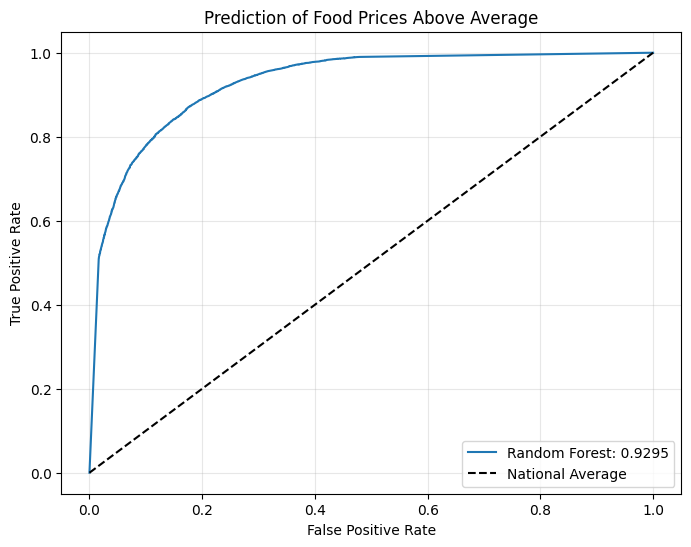

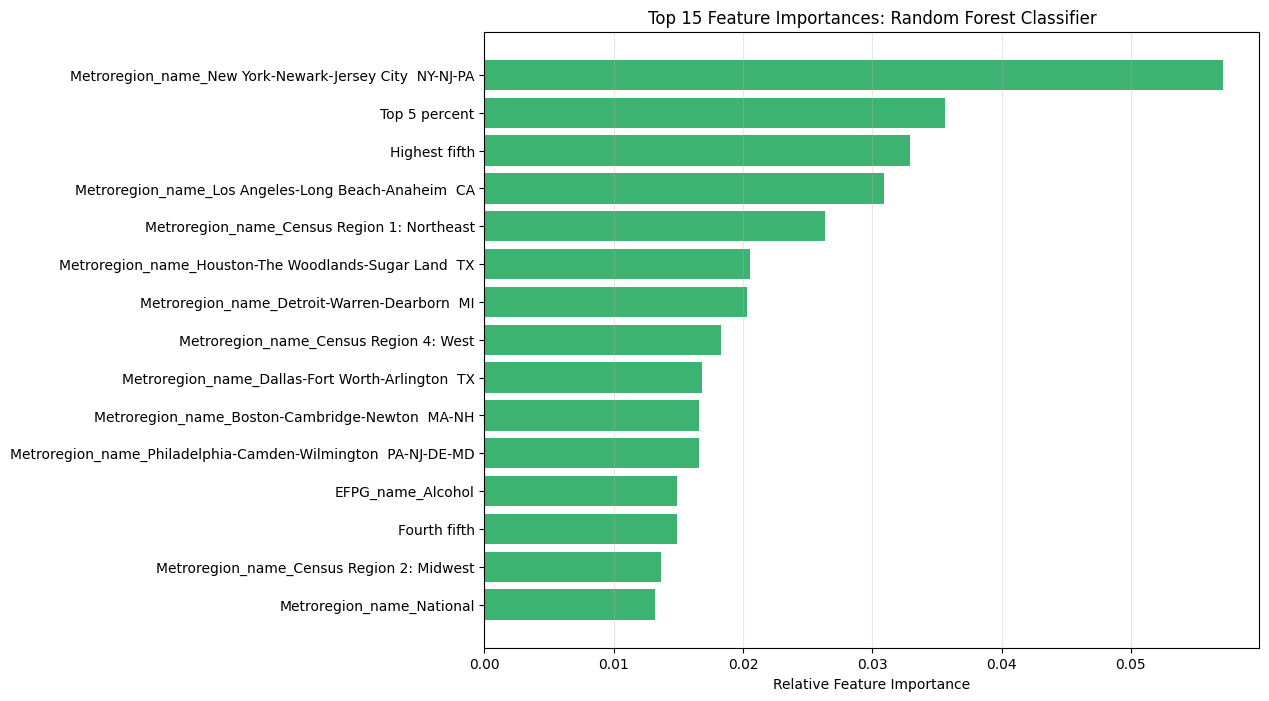

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import StandardScaler

df_fmap = pd.read_csv('Cleaned_FMAP.csv')
df_income = pd.read_csv('Cleaned_Income.csv')
df = pd.merge(df_fmap, df_income, on='Year', how='inner')

df['High_Price'] = np.where(df['Price_index_GEKS'] > 1.0, 1, 0)
features = ['Lowest fifth', 'Second fifth', 'Third fifth', 'Fourth fifth', 'Highest fifth',
            'Top 5 percent', 'Metroregion_name', 'EFPG_name']
X = df[features]
X = pd.get_dummies(X, columns=['Metroregion_name', 'EFPG_name'], drop_first=True)
y = df['High_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = auc(fpr_log, tpr_log)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, log_reg.predict(X_test_scaled)))
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_clf.predict(X_test)))

plt.figure(figsize=(8, 6))
#plt.plot(fpr_log, tpr_log, label=f'Logistic Regression: {auc_log:.4f}')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest: {auc_rf:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='National Average')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Prediction of Food Prices Above Average')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('average_pricerandom.png')
plt.show()
